In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "sales_data.csv",
    encoding="latin1"
)

print("Dataset chargé :", df.shape)


In [ ]:
print("Pandas :", pd.__version__)
print("NumPy :", np.__version__)
print("Matplotlib :", plt.matplotlib.__version__)
print("Seaborn :", sns.__version__)


# Méthode de nettoyage et exploration des données

## 1. Introduction

### Contexte

L'analyse de données constitue une étape essentielle pour transformer des données brutes en informations exploitables pour la prise de décision.

Dans le cadre de ce projet, nous travaillons sur un jeu de données relatif aux ventes de produits. Le dataset contient des informations concernant les commandes, les produits, les clients, les dates de vente, les marchés et le chiffre d'affaires.

### Objectif du projet

L'objectif principal de ce projet est de mettre en œuvre une démarche structurée de **nettoyage, préparation et exploration des données**, afin d'obtenir un jeu de données fiable et d'en extraire des informations pertinentes sur les performances commerciales.

L'analyse vise notamment à :

- évaluer la qualité et la structure initiale des données ;
- identifier et traiter les valeurs manquantes ;
- vérifier la présence de doublons et d'anomalies ;
- préparer les variables nécessaires à l'analyse ;
- explorer les performances commerciales selon les produits, les marchés et les tailles de vente ;
- analyser l'évolution du chiffre d'affaires dans le temps ;
- étudier les relations entre les principales variables quantitatives ;
- identifier les valeurs potentiellement aberrantes ;
- dégager les principaux enseignements et formuler des recommandations à partir des résultats obtenus.

### Démarche

L'analyse suivra les principales étapes suivantes :

1. Découverte et compréhension du dataset ;
2. Diagnostic de la qualité des données ;
3. Nettoyage et préparation des données ;
4. Exploration et visualisation des données ;
5. Analyse des performances commerciales ;
6. Analyse temporelle et recherche de tendances ;
7. Analyse des relations entre variables ;
8. Détection et traitement des valeurs aberrantes ;
9. Synthèse des principaux résultats ;
10. Recommandations et conclusion.

## 2. Découverte et compréhension du dataset

Cette première étape consiste à examiner la structure du jeu de données avant toute opération de nettoyage ou de transformation.

In [ ]:
print("Dimensions de df :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [34]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


### Première observation

Le jeu de données contient **2 823 lignes et 25 colonnes**. Il regroupe des informations relatives aux commandes, aux produits, aux clients, aux dates et aux performances commerciales.

Les variables quantitatives principales sont notamment `QUANTITYORDERED`, `PRICEEACH`, `SALES` et `MSRP`, tandis que plusieurs variables catégorielles permettent de caractériser les produits, les marchés et les commandes.

Cette première exploration permet de comprendre la structure du dataset avant d'entreprendre les opérations de nettoyage et de préparation.

### Analyse descriptive initiale

Les statistiques descriptives montrent que la quantité moyenne commandée est de **35,09 unités**, avec une médiane de **35 unités**. Les quantités observées varient de 6 à 97 unités.

Le prix unitaire (`PRICEEACH`) présente une moyenne de **83,66**, tandis que sa médiane est de **95,70**. Les valeurs observées sont comprises entre **26,88 et 100**.

Le chiffre d'affaires (`SALES`) présente une moyenne de **3 553,89** par ligne de vente et une médiane de **3 184,80**. Les valeurs s'étendent de **482,13 à 14 082,80**, ce qui indique une dispersion importante des montants de vente.

Le `MSRP` présente une moyenne de **100,72**, avec des valeurs comprises entre **33 et 214**.

Enfin, les dates de commande couvrent la période du **6 janvier 2003 au 31 mai 2005**. L'année 2005 étant partielle, les comparaisons annuelles impliquant cette année devront être interprétées avec prudence.

### Vérification initiale des valeurs manquantes

Avant le nettoyage, une vérification des valeurs manquantes est réalisée afin d'identifier les variables nécessitant un traitement particulier.

## 3. Nettoyage et préparation des données

### 3.1 Traitement des valeurs manquantes

L'analyse initiale a permis d'identifier plusieurs valeurs manquantes dans les variables liées aux informations géographiques et aux adresses des clients.

Les valeurs manquantes concernent principalement `ADDRESSLINE2`, `STATE`, `POSTALCODE` et `TERRITORY`.

### Diagnostic initial

Le dataset contenait initialement **5 157 valeurs manquantes** réparties sur quatre variables.

In [ ]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Valeurs_manquantes": missing_values,
    "Pourcentage": (missing_values / len(df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Valeurs_manquantes"] > 0
]

print("Valeurs manquantes avant traitement :")
display(missing_table)

print(
    "\nNombre total de valeurs manquantes :",
    missing_values.sum()
)


### Traitement

Afin de conserver toutes les observations et de ne pas supprimer des lignes contenant des informations commerciales utiles, les valeurs manquantes des variables catégorielles ont été remplacées par la modalité `Unknown`.

Cette approche permet de distinguer une information réellement absente d'une observation supprimée et préserve les 2 823 lignes du dataset.

In [37]:
columns_to_fill = [
    "ADDRESSLINE2",
    "STATE",
    "POSTALCODE",
    "TERRITORY"
]

df[columns_to_fill] = df[columns_to_fill].fillna("Unknown")

In [38]:
print("Nombre total de valeurs manquantes après traitement :", df.isnull().sum().sum())

Nombre total de valeurs manquantes après traitement : 0


### 3.2 Vérification des doublons

La présence éventuelle de lignes dupliquées est vérifiée afin d'éviter qu'une même observation soit comptabilisée plusieurs fois dans les analyses.

In [39]:
duplicates = df.duplicated().sum()

print("Nombre de lignes dupliquées :", duplicates)

Nombre de lignes dupliquées : 0


### Résultat

Aucun doublon n'a été détecté dans le dataset. Aucune suppression de ligne n'a donc été nécessaire à cette étape.

### 3.3 Conversion et préparation de la variable de date

La variable `ORDERDATE` doit être convertie au format datetime afin de permettre les analyses temporelles, notamment l'extraction du mois, de l'année, du trimestre et l'étude de la saisonnalité.

In [40]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

In [41]:
print(df["ORDERDATE"].dtype)

datetime64[us]


### Extraction des composantes temporelles

À partir de `ORDERDATE`, plusieurs informations temporelles sont extraites afin de faciliter l'analyse de l'évolution des ventes.

In [42]:
df["ORDER_YEAR"] = df["ORDERDATE"].dt.year
df["ORDER_MONTH"] = df["ORDERDATE"].dt.month
df["ORDER_QUARTER"] = df["ORDERDATE"].dt.quarter
df["ORDER_MONTH_NAME"] = df["ORDERDATE"].dt.month_name()
df["ORDER_DAY_NAME"] = df["ORDERDATE"].dt.day_name()

In [43]:
df[
    [
        "ORDERDATE",
        "ORDER_YEAR",
        "ORDER_MONTH",
        "ORDER_QUARTER",
        "ORDER_MONTH_NAME",
        "ORDER_DAY_NAME"
    ]
].head()

,ORDERDATE,ORDER_YEAR,ORDER_MONTH,ORDER_QUARTER,ORDER_MONTH_NAME,ORDER_DAY_NAME
0,2003-02-24,2003,2,1,February,Monday
1,2003-05-07,2003,5,2,May,Wednesday
2,2003-07-01,2003,7,3,July,Tuesday
3,2003-08-25,2003,8,3,August,Monday
4,2003-10-10,2003,10,4,October,Friday


### 3.4 Vérification finale de la qualité des données

Après les opérations de nettoyage, une nouvelle vérification est réalisée afin de confirmer que le dataset est exploitable pour les analyses suivantes.

In [20]:
print("Dimensions du dataset :", df.shape)
print("Nombre total de valeurs manquantes :", df.isnull().sum().sum())
print("Nombre de doublons :", df.duplicated().sum())
print("Type de ORDERDATE :", df["ORDERDATE"].dtype)

Dimensions du dataset : (2823, 30)
Nombre total de valeurs manquantes : 0
Nombre de doublons : 0
Type de ORDERDATE : datetime64[us]


### Bilan du nettoyage

Le nettoyage a permis de conserver l'intégralité des **2 823 observations** tout en supprimant les valeurs manquantes résiduelles et en vérifiant l'absence de doublons.

Les variables temporelles ont également été préparées à partir de `ORDERDATE`, permettant de réaliser les analyses chronologiques et saisonnières.

Le dataset est désormais suffisamment préparé pour passer à la phase d'exploration et d'analyse des performances commerciales.

## 4. Exploration des données

### 4.1 Distribution des statuts de commande

L'analyse des statuts permet d'évaluer la répartition des lignes de vente selon leur état de traitement.

In [21]:
status_counts = df["STATUS"].value_counts()

status_counts

STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64

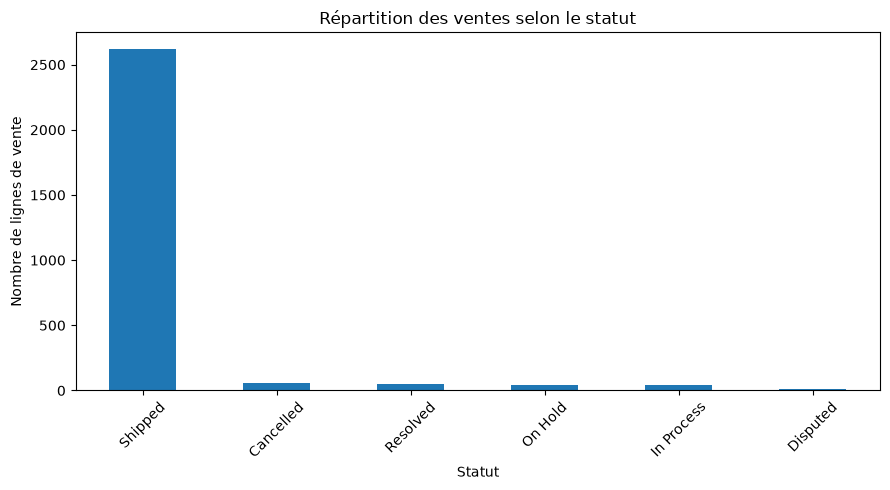

In [22]:
plt.figure(figsize=(9, 5))

status_counts.plot(kind="bar")

plt.title("Répartition des ventes selon le statut")
plt.xlabel("Statut")
plt.ylabel("Nombre de lignes de vente")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interprétation

Le statut `Shipped` domine très largement avec **2 617 lignes sur 2 823**, soit environ **92,7 %** des lignes de vente.

Les autres statuts représentent une proportion nettement plus faible des observations.

Cette distribution indique que la majorité des lignes de vente enregistrées correspondent à des commandes expédiées.

Cette analyse permet également d'identifier les statuts minoritaires tels que `Disputed`, `On Hold` ou `Cancelled`, qui peuvent nécessiter une attention particulière dans une analyse opérationnelle.

### 4.2 Performance commerciale par gamme de produits

L'objectif est d'identifier les gammes qui contribuent le plus au chiffre d'affaires et de comparer leur volume de ventes.

In [46]:
sales_by_product = (
    df.groupby("PRODUCTLINE")["SALES"]
      .agg(["count", "sum", "mean", "median"])
      .sort_values("sum", ascending=False)
)

sales_by_product

,count,sum,mean,median
PRODUCTLINE,,,,
Classic Cars,967,3919615.66,4053.377104,3761.370
Vintage Cars,607,1903150.84,3135.339110,2795.270
Motorcycles,331,1166388.34,3523.831843,3127.820
Trucks and Buses,301,1127789.84,3746.810100,3449.400
Planes,306,975003.57,3186.286176,2841.805
Ships,234,714437.13,3053.150128,2884.925
Trains,77,226243.47,2938.226883,2445.600


In [47]:
sales_by_product["sales_percentage"] = (
    sales_by_product["sum"]
    / sales_by_product["sum"].sum()
    * 100
)

sales_by_product

,count,sum,mean,median,sales_percentage
PRODUCTLINE,,,,,
Classic Cars,967,3919615.66,4053.377104,3761.370,39.068680
Vintage Cars,607,1903150.84,3135.339110,2795.270,18.969613
Motorcycles,331,1166388.34,3523.831843,3127.820,11.625949
Trucks and Buses,301,1127789.84,3746.810100,3449.400,11.241220
Planes,306,975003.57,3186.286176,2841.805,9.718326
Ships,234,714437.13,3053.150128,2884.925,7.121136
Trains,77,226243.47,2938.226883,2445.600,2.255077


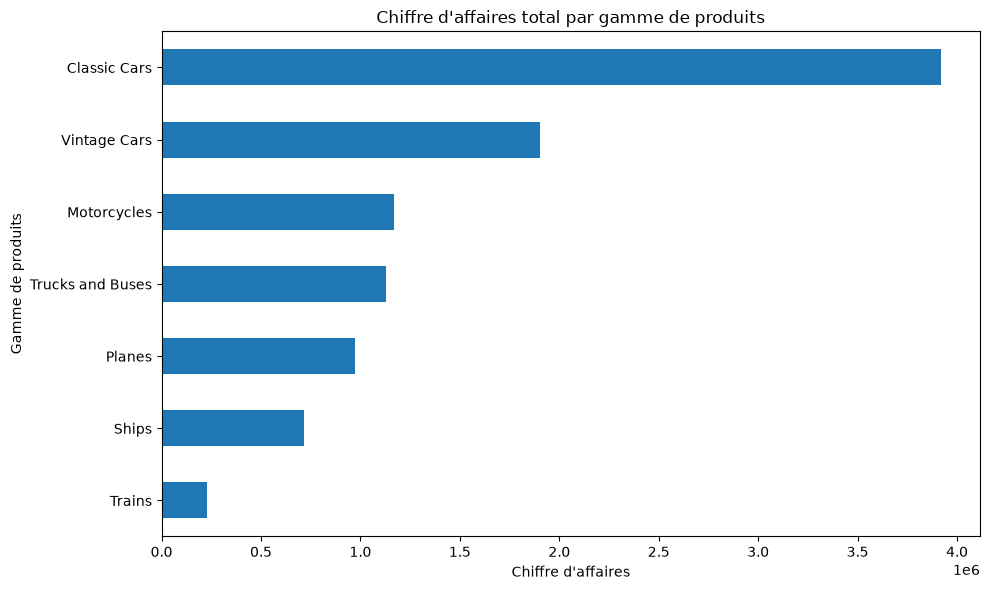

In [48]:
plt.figure(figsize=(10, 6))

sales_by_product["sum"].sort_values().plot(kind="barh")

plt.title("Chiffre d'affaires total par gamme de produits")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Gamme de produits")

plt.tight_layout()
plt.show()

### Interprétation

`Classic Cars` constitue la gamme générant le chiffre d'affaires total le plus élevé avec **3 919 615,66**, soit **39,07 % du chiffre d'affaires total**.

`Vintage Cars` arrive en deuxième position avec **18,97 %**.

Les deux gammes représentent ensemble **58,04 % du chiffre d'affaires total**, ce qui révèle une concentration importante de la performance commerciale sur ces deux catégories.

Cette concentration constitue un élément important à prendre en compte dans l'interprétation de la performance globale.

### 4.3 Performance commerciale par pays

L'analyse par pays permet d'identifier les marchés contribuant le plus au chiffre d'affaires.

In [439]:
sales_by_country = (
    df.groupby("COUNTRY")["SALES"]
      .agg(["count", "sum", "mean", "median"])
      .sort_values("sum", ascending=False)
)

sales_by_country.head(10)

,count,sum,mean,median
COUNTRY,,,,
USA,1004,3627982.83,3613.528715,3236.060
Spain,342,1215686.92,3554.640117,3213.805
France,314,1110916.52,3537.950701,3154.305
Australia,185,630623.10,3408.773514,3070.400
UK,144,478880.46,3325.558750,3122.470
Italy,113,374674.31,3315.701858,2915.660
Finland,92,329581.91,3582.412065,3247.830
Norway,85,307463.70,3617.220000,3394.980
Singapore,79,288488.41,3651.752025,3127.880


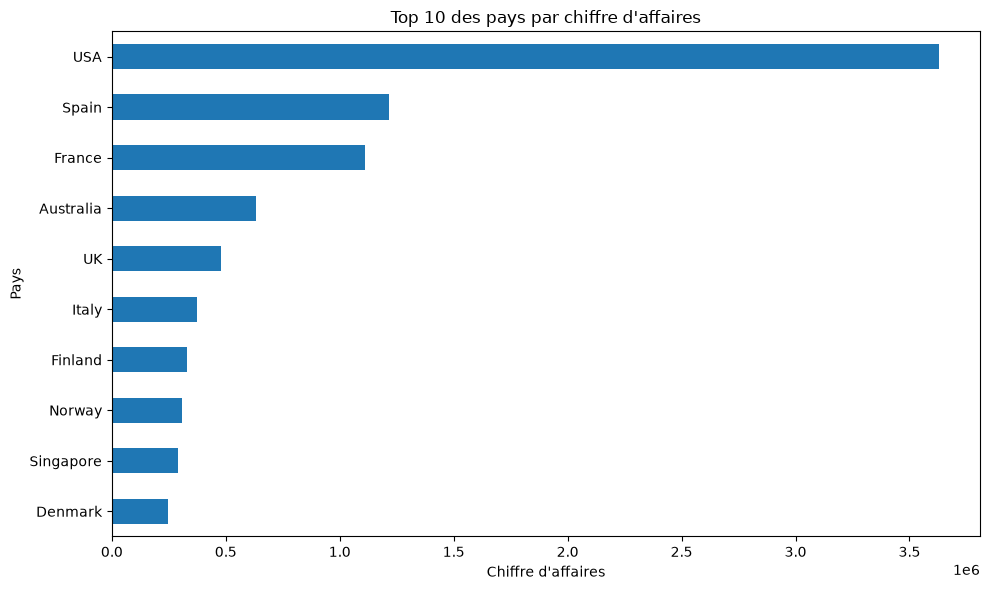

In [440]:
plt.figure(figsize=(10, 6))

sales_by_country["sum"].head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des pays par chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Pays")

plt.tight_layout()
plt.show()

### Interprétation

Les États-Unis constituent le premier marché avec **3 627 982,83** de chiffre d'affaires et **1 004 lignes de vente**.

L'Espagne et la France arrivent ensuite, mais avec des niveaux de chiffre d'affaires nettement inférieurs.

Les États-Unis représentent donc le principal marché observé dans le dataset en termes de chiffre d'affaires et de volume de lignes de vente.

Cette conclusion concerne la performance commerciale mesurée par le chiffre d'affaires et ne permet pas de conclure directement sur la rentabilité des marchés.

### 4.4 Performance selon la taille des ventes

L'analyse de `DEALSIZE` permet de comparer la contribution au chiffre d'affaires des ventes classées comme `Small`, `Medium` et `Large`.

In [441]:
revenue_by_dealsize = (
    df.groupby("DEALSIZE")["SALES"]
      .agg(["count", "sum", "mean", "median"])
      .sort_values("sum", ascending=False)
)

revenue_by_dealsize

,count,sum,mean,median
DEALSIZE,,,,
Medium,1384,6087432.24,4398.433699,4162.750
Small,1282,2643077.35,2061.682800,2113.975
Large,157,1302119.26,8293.753248,8008.560


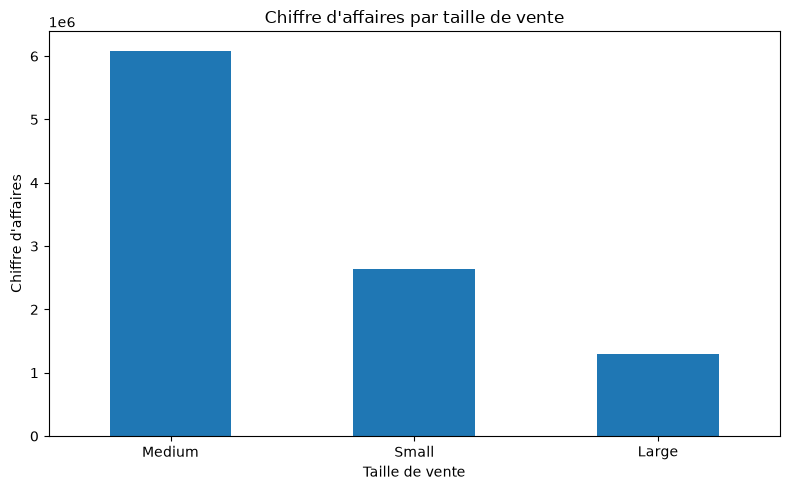

In [442]:
plt.figure(figsize=(8, 5))

revenue_by_dealsize["sum"].plot(kind="bar")

plt.title("Chiffre d'affaires par taille de vente")
plt.xlabel("Taille de vente")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interprétation

Les ventes `Medium` représentent **6 087 432,24**, soit **60,68 % du chiffre d'affaires total**.

Elles constituent donc le principal contributeur au chiffre d'affaires.

Cependant, les ventes `Large` présentent le chiffre d'affaires moyen par ligne le plus élevé, avec **8 293,75**, contre **4 398,43** pour `Medium` et **2 061,68** pour `Small`.

Il existe donc une différence importante entre la fréquence d'un segment et sa valeur moyenne : `Medium` domine en contribution totale, tandis que `Large` présente une valeur moyenne par ligne nettement supérieure.

#### Analyse croisée : gamme de produits et taille des ventes

Le croisement entre `PRODUCTLINE` et `DEALSIZE` permet de préciser la contribution de chaque gamme au chiffre d'affaires selon la taille des ventes.

In [4]:
sales_product_dealsize = (
    df.groupby(["PRODUCTLINE", "DEALSIZE"])["SALES"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

sales_product_dealsize

count         sum         mean
PRODUCTLINE      DEALSIZE                                
Classic Cars     Medium      530  2430258.39  4585.393189
Vintage Cars     Medium      261  1085539.96  4159.156935
Trucks and Buses Medium      175   817027.68  4668.729600
Classic Cars     Large        97   796641.79  8212.801959
                 Small       340   692715.48  2037.398471
Motorcycles      Medium      156   680369.69  4361.344167
Vintage Cars     Small       322   608542.83  1889.884565
Planes           Medium      129   538606.05  4175.240698
Ships            Medium      107   422735.07  3950.795047
Planes           Small       168   364365.82  2168.844167
Motorcycles      Small       156   326874.04  2095.346410
Ships            Small       127   291702.06  2296.866614
Trucks and Buses Small       119   254506.10  2138.706723
Vintage Cars     Large        24   209068.05  8711.168750
Motorcycles      Large        19   159144.61  8376.032105
Trains           Medium       26   112895.40  4342.130769
                 Small        50   104371.02  2087.420400
Planes           Large         9    72031.70  8003.522222
Trucks and Buses Large         7    56256.06  8036.580000
Trains           Large         1     8977.05  8977.050000

In [5]:
sales_pivot = sales_product_dealsize["sum"].unstack()

sales_pivot

DEALSIZE,Large,Medium,Small
PRODUCTLINE,,,
Classic Cars,796641.79,2430258.39,692715.48
Motorcycles,159144.61,680369.69,326874.04
Planes,72031.70,538606.05,364365.82
Ships,NaN,422735.07,291702.06
Trains,8977.05,112895.40,104371.02
Trucks and Buses,56256.06,817027.68,254506.10
Vintage Cars,209068.05,1085539.96,608542.83


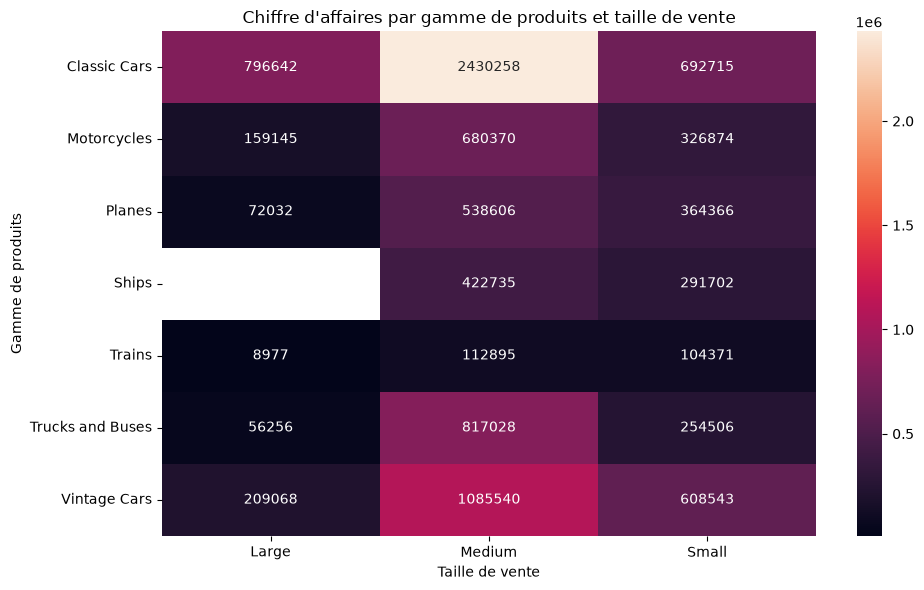

In [6]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    sales_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Chiffre d'affaires par gamme de produits et taille de vente")
plt.xlabel("Taille de vente")
plt.ylabel("Gamme de produits")
plt.tight_layout()
plt.show()

### Interprétation

Le croisement entre `PRODUCTLINE` et `DEALSIZE` montre que `Classic Cars` réalise son principal chiffre d'affaires dans les ventes `Medium`, avec **2 430 258,39**. Les ventes `Large` représentent également une contribution importante, avec **796 641,79**.

Cette analyse permet donc de préciser la position dominante de `Classic Cars` : sa performance globale est principalement portée par les ventes `Medium`, tout en étant soutenue par les ventes `Large`.

### Décision

`Classic Cars` doit rester une gamme prioritaire dans le suivi de la performance commerciale. Une attention particulière peut être portée aux ventes `Medium`, qui constituent son principal contributeur au chiffre d'affaires, tout en surveillant les ventes `Large`, dont le chiffre d'affaires moyen est élevé.

In [49]:
quantity_by_product = (
    df.groupby("PRODUCTLINE")["QUANTITYORDERED"]
      .agg(["count", "sum", "mean", "median"])
      .sort_values("sum", ascending=False)
)

quantity_by_product

,count,sum,mean,median
PRODUCTLINE,,,,
Classic Cars,967,33992,35.152017,35.0
Vintage Cars,607,21069,34.710049,34.0
Motorcycles,331,11663,35.235650,35.0
Trucks and Buses,301,10777,35.803987,36.0
Planes,306,10727,35.055556,34.0
Ships,234,8127,34.730769,34.5
Trains,77,2712,35.220779,35.0


In [50]:
product_performance = (
    df.groupby("PRODUCTLINE")
      .agg(
          QUANTITY_MEAN=("QUANTITYORDERED", "mean"),
          SALES_MEAN=("SALES", "mean")
      )
      .sort_values("SALES_MEAN", ascending=False)
)

product_performance

,QUANTITY_MEAN,SALES_MEAN
PRODUCTLINE,,
Classic Cars,35.152017,4053.377104
Trucks and Buses,35.803987,3746.810100
Motorcycles,35.235650,3523.831843
Planes,35.055556,3186.286176
Vintage Cars,34.710049,3135.339110
Ships,34.730769,3053.150128
Trains,35.220779,2938.226883


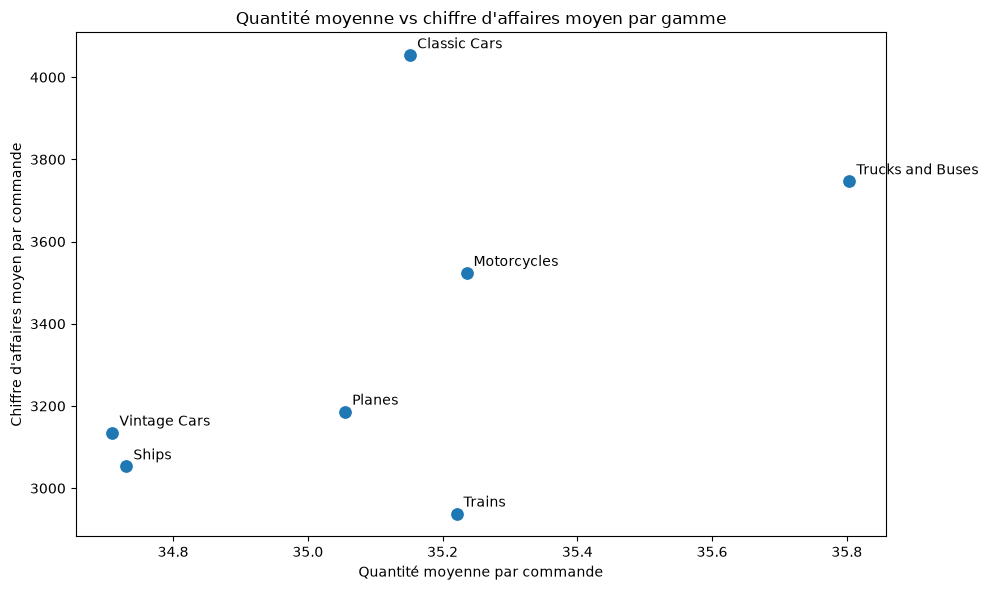

In [51]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_performance,
    x="QUANTITY_MEAN",
    y="SALES_MEAN",
    s=100
)

for product, row in product_performance.iterrows():
    plt.annotate(
        product,
        (row["QUANTITY_MEAN"], row["SALES_MEAN"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Quantité moyenne vs chiffre d'affaires moyen par gamme")
plt.xlabel("Quantité moyenne par commande")
plt.ylabel("Chiffre d'affaires moyen par commande")

plt.tight_layout()
plt.show()

### Interprétation

Les quantités moyennes commandées sont relativement proches entre les différentes gammes, autour de 35 unités par ligne.

La différence de chiffre d'affaires entre les gammes ne semble donc pas être expliquée uniquement par la quantité moyenne commandée.

Cette observation justifie l'analyse complémentaire du prix unitaire et du chiffre d'affaires.

## 5. Analyse temporelle

### 5.1 Évolution annuelle du chiffre d'affaires

L'analyse annuelle permet d'observer l'évolution du chiffre d'affaires au cours de la période couverte par le dataset.

Une attention particulière est portée à la comparaison entre 2003 et 2004, qui correspondent aux deux années complètes disponibles.

In [444]:
yearly_sales = (
    df.groupby("YEAR_ID")["SALES"]
      .agg(["count", "sum", "mean", "median"])
)

yearly_sales

,count,sum,mean,median
YEAR_ID,,,,
2003,1000,3516979.54,3516.979540,3210.095
2004,1345,4724162.60,3512.388550,3141.570
2005,478,1791486.71,3747.880146,3316.815


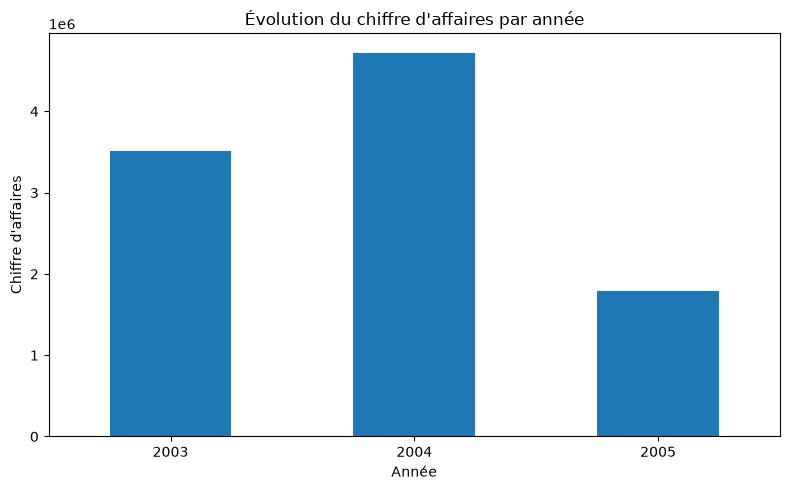

In [445]:
plt.figure(figsize=(8, 5))

yearly_sales["sum"].plot(kind="bar")

plt.title("Évolution du chiffre d'affaires par année")
plt.xlabel("Année")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [446]:
variation_2003_2004 = (
    (yearly_sales.loc[2004, "sum"] - yearly_sales.loc[2003, "sum"])
    / yearly_sales.loc[2003, "sum"]
) * 100

print(
    "Variation du CA entre 2003 et 2004 :",
    round(variation_2003_2004, 2),
    "%"
)

Variation du CA entre 2003 et 2004 : 34.32 %


### Interprétation

Le chiffre d'affaires est passé de **3 516 979,54** en 2003 à **4 724 162,60** en 2004.

Cette évolution représente une progression de **34,32 %**.

Les années 2003 et 2004 étant complètes dans le dataset, cette comparaison constitue une base fiable pour mesurer l'évolution annuelle de l'activité.

L'année 2005 ne doit pas être comparée directement en termes de chiffre d'affaires total, car les données disponibles s'arrêtent au mois de mai.

### Décision

La progression de **34,32 %** entre 2003 et 2004 constitue un indicateur positif de l'évolution du chiffre d'affaires et sera retenue comme insight principal de l'analyse temporelle.

### 5.2 Évolution mensuelle du chiffre d'affaires

L'analyse mensuelle permet d'identifier les périodes de forte et de faible activité et de rechercher une éventuelle saisonnalité des ventes.

In [447]:
monthly_sales = (
    df.groupby(
        df["ORDERDATE"].dt.to_period("M")
    )["SALES"]
    .sum()
)

monthly_sales.head()

ORDERDATE
2003-01    129753.60
2003-02    140836.19
2003-03    174504.90
2003-04    201609.55
2003-05    192673.11
Freq: M, Name: SALES, dtype: float64

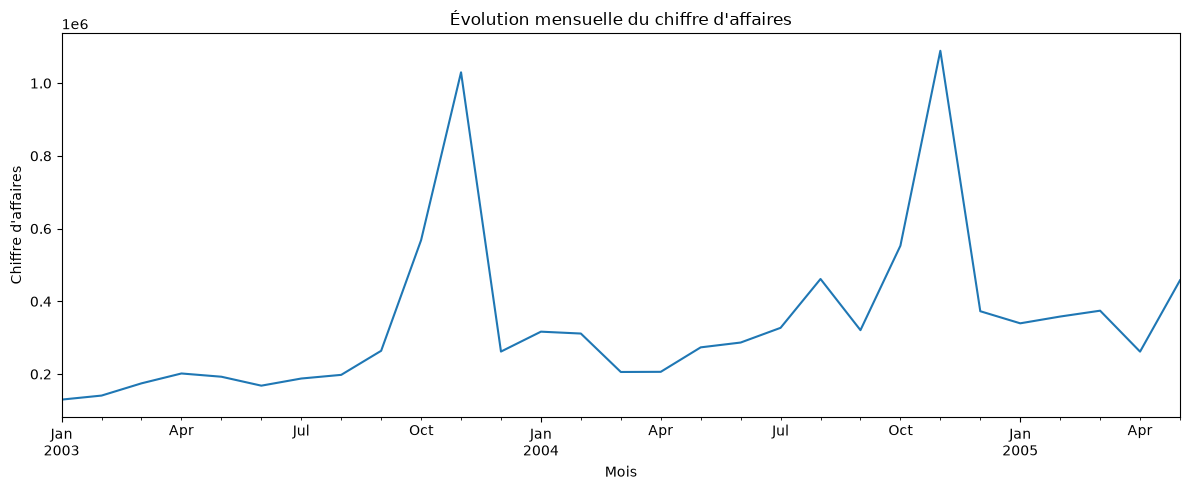

In [448]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Évolution mensuelle du chiffre d'affaires")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")

plt.tight_layout()
plt.show()

In [449]:
top_months = monthly_sales.sort_values(ascending=False).head(10)

print("Top 10 mois par chiffre d'affaires :")
print(top_months)

Top 10 mois par chiffre d'affaires :
ORDERDATE
2004-11    1089048.01
2003-11    1029837.66
2003-10     568290.97
2004-10     552924.25
2004-08     461501.27
2005-05     457861.06
2005-03     374262.76
2004-12     372802.66
2005-02     358186.18
2005-01     339543.42
Freq: M, Name: SALES, dtype: float64


### Interprétation

L'analyse mensuelle met en évidence une forte concentration du chiffre d'affaires en fin d'année.

Les deux mois les plus performants de l'ensemble de la période sont **novembre 2004**, avec **1 089 048,01**, et **novembre 2003**, avec **1 029 837,66**.

Les mois d'octobre 2003 (**568 290,97**) et d'octobre 2004 (**552 924,25**) présentent également des niveaux élevés.

La répétition de cette concentration en octobre et novembre sur les deux années complètes observées suggère l'existence d'une **saisonnalité favorable aux ventes en fin d'année**.

### Limite d'interprétation

La saisonnalité observée constitue une tendance importante, mais elle doit être interprétée avec prudence.

Le dataset couvre deux années complètes, 2003 et 2004, tandis que 2005 est partielle et s'arrête en mai. Le nombre de cycles annuels complets disponibles reste donc limité.

De plus, les données ne contiennent pas suffisamment d'informations pour déterminer la cause du pic observé en octobre-novembre. Il n'est donc pas possible d'attribuer directement cette hausse à une promotion, une campagne marketing ou un événement commercial particulier.

### Décision

La concentration récurrente des ventes en octobre et novembre est conservée comme **insight temporel majeur**.

Elle peut notamment justifier une attention particulière à la préparation commerciale et opérationnelle de cette période, sans toutefois considérer que la cause du phénomène est établie.

## 6. Analyse des relations entre variables

Cette étape vise à étudier les relations entre les principales variables quantitatives du dataset, en particulier celles susceptibles d'être associées au chiffre d'affaires (`SALES`).

L'objectif est d'identifier les associations linéaires entre les variables et de déterminer quelles variables présentent les relations les plus importantes avec le chiffre d'affaires.

In [450]:
numeric_cols = [
    "QUANTITYORDERED",
    "PRICEEACH",
    "SALES",
    "MSRP"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,QUANTITYORDERED,PRICEEACH,SALES,MSRP
QUANTITYORDERED,1.000000,0.005564,0.551426,0.017881
PRICEEACH,0.005564,1.000000,0.657841,0.670625
SALES,0.551426,0.657841,1.000000,0.635239
MSRP,0.017881,0.670625,0.635239,1.000000


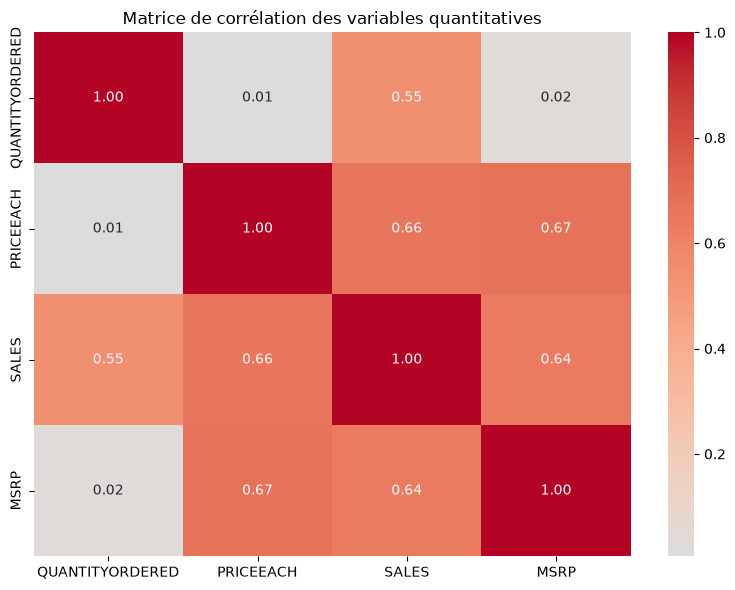

In [451]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables quantitatives")

plt.tight_layout()
plt.show()

### Analyse des corrélations avec le chiffre d'affaires

La corrélation entre `PRICEEACH` et `SALES` est de **0,6578**, ce qui représente la relation linéaire positive la plus forte parmi les principales variables étudiées.

La corrélation entre `MSRP` et `SALES` est également positive et relativement élevée, avec un coefficient de **0,6352**.

La quantité commandée (`QUANTITYORDERED`) présente une corrélation positive de **0,5514** avec le chiffre d'affaires.

Ces résultats montrent que les trois variables sont positivement associées au chiffre d'affaires, mais avec des intensités différentes.

### Résultat principal

La corrélation entre `PRICEEACH` et `SALES` (**0,6578**) est supérieure à celle entre `QUANTITYORDERED` et `SALES` (**0,5514**).

Dans ce dataset, le prix unitaire présente donc une association linéaire plus forte avec le chiffre d'affaires que la quantité commandée.

### Décision

Cette observation est retenue comme insight analytique secondaire : le prix unitaire présente la relation linéaire la plus forte avec le chiffre d'affaires parmi les variables étudiées.

Cependant, ce résultat ne signifie pas qu'une augmentation du prix entraîne nécessairement une augmentation du chiffre d'affaires.

### Limite d'interprétation

Une corrélation mesure l'intensité d'une association linéaire entre deux variables, mais elle ne permet pas d'établir une relation de cause à effet.

Ainsi, la corrélation de **0,6578** entre `PRICEEACH` et `SALES` ne permet pas d'affirmer qu'une augmentation du prix provoque directement une augmentation du chiffre d'affaires.

D'autres facteurs peuvent intervenir, notamment la quantité vendue, le produit, la taille de la vente ou les caractéristiques du marché.

### Remarque méthodologique

La matrice montre également de fortes corrélations entre certaines variables temporelles, notamment `QTR_ID` et `MONTH_ID` (**0,9793**).

Cette relation est cohérente avec la construction des variables, puisque le trimestre est directement lié au mois.

De même, la forte corrélation entre `ORDERNUMBER` et `YEAR_ID` (**0,9046**) reflète principalement la progression chronologique des numéros de commande.

Ces relations ne sont donc pas interprétées comme des facteurs explicatifs de la performance commerciale.

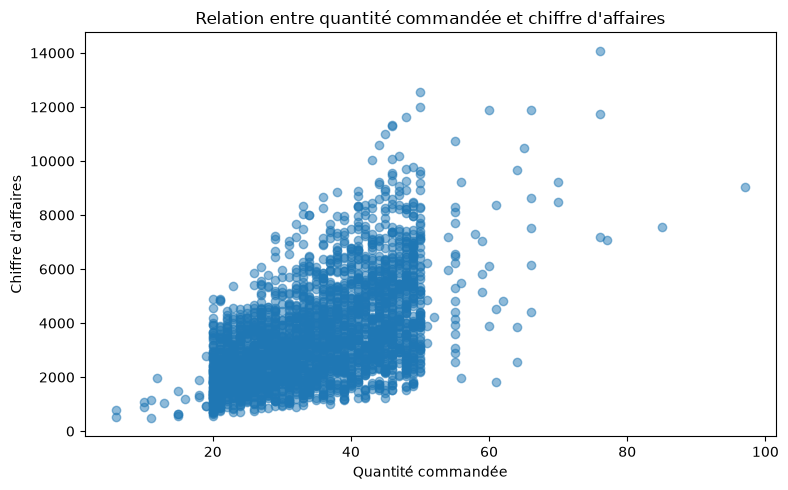

In [452]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["QUANTITYORDERED"],
    df["SALES"],
    alpha=0.5
)

plt.title("Relation entre quantité commandée et chiffre d'affaires")
plt.xlabel("Quantité commandée")
plt.ylabel("Chiffre d'affaires")

plt.tight_layout()
plt.show()

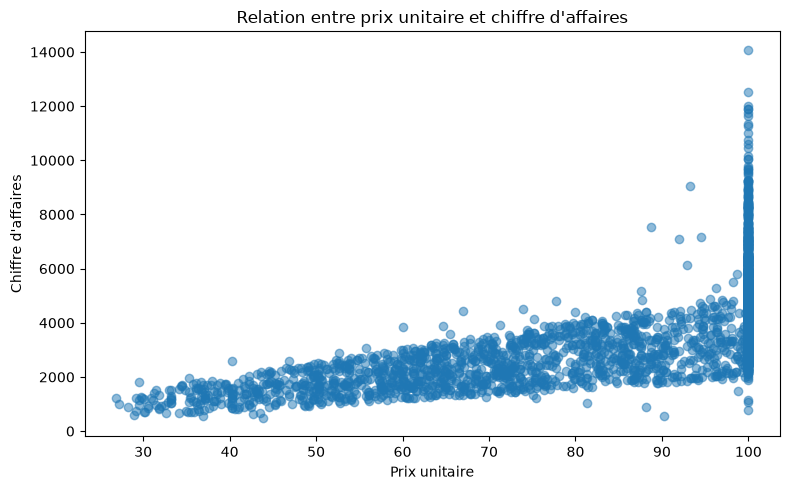

In [453]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["PRICEEACH"],
    df["SALES"],
    alpha=0.5
)

plt.title("Relation entre prix unitaire et chiffre d'affaires")
plt.xlabel("Prix unitaire")
plt.ylabel("Chiffre d'affaires")

plt.tight_layout()
plt.show()

## 7. Détection et analyse des valeurs aberrantes

Les valeurs aberrantes correspondent à des observations qui s'écartent fortement de la distribution générale d'une variable.

Dans cette analyse, la méthode de l'intervalle interquartile (IQR) est utilisée pour identifier les observations potentiellement atypiques au niveau du chiffre d'affaires.

La détection statistique d'une valeur extrême ne signifie toutefois pas nécessairement qu'il s'agit d'une erreur de données. Une vérification complémentaire est donc nécessaire avant toute décision de suppression.

In [454]:
Q1 = df["SALES"].quantile(0.25)
Q3 = df["SALES"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Limite inférieure :", lower_bound)
print("Limite supérieure :", upper_bound)

Q1 : 2203.4300000000003
Q3 : 4508.0
IQR : 2304.5699999999997
Limite inférieure : -1253.4249999999993
Limite supérieure : 7964.855


In [455]:
outliers = df[
    (df["SALES"] < lower_bound) |
    (df["SALES"] > upper_bound)
]

print("Nombre de valeurs aberrantes :", len(outliers))
print(
    "Pourcentage de valeurs aberrantes :",
    round(len(outliers) / len(df) * 100, 2),
    "%"
)

Nombre de valeurs aberrantes : 81
Pourcentage de valeurs aberrantes : 2.87 %


### Examen des observations atypiques

Les observations identifiées comme potentiellement aberrantes sont examinées à partir de plusieurs variables afin de déterminer si elles correspondent à des erreurs ou à des transactions commerciales exceptionnellement élevées.

In [456]:
outliers[
    [
        "ORDERNUMBER",
        "QUANTITYORDERED",
        "PRICEEACH",
        "SALES",
        "PRODUCTLINE",
        "DEALSIZE",
        "STATUS"
    ]
].sort_values("SALES", ascending=False).head(20)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,PRODUCTLINE,DEALSIZE,STATUS
598,10407,76,100.0,14082.80,Vintage Cars,Large,On Hold
744,10322,50,100.0,12536.50,Vintage Cars,Large,Shipped
53,10424,50,100.0,12001.00,Classic Cars,Large,In Process
1062,10412,60,100.0,11887.80,Classic Cars,Large,Shipped
104,10403,66,100.0,11886.60,Motorcycles,Large,Shipped
1995,10405,76,100.0,11739.70,Classic Cars,Large,Shipped
44,10312,48,100.0,11623.70,Classic Cars,Large,Shipped
1133,10333,46,100.0,11336.70,Vintage Cars,Large,Shipped
188,10127,46,100.0,11279.20,Classic Cars,Large,Shipped
30,10150,45,100.0,10993.50,Classic Cars,Large,Shipped


### Analyse

Les observations identifiées présentent généralement des montants de vente élevés et sont souvent associées à des quantités importantes et à la catégorie `Large`.

Ces observations ne présentent pas nécessairement de caractéristiques indiquant une erreur de saisie. Elles peuvent correspondre à des transactions commerciales de valeur élevée.

Par conséquent, le simple fait qu'une observation soit statistiquement atypique ne constitue pas une justification suffisante pour la supprimer.

### Décision

Les **81 observations potentiellement aberrantes** sont conservées dans le dataset.

Cette décision repose sur le fait qu'aucune preuve suffisante ne permet de considérer ces observations comme des erreurs de données.

Les supprimer automatiquement aurait pour conséquence de réduire artificiellement le chiffre d'affaires observé et pourrait conduire à une représentation biaisée de la performance commerciale.

Les valeurs extrêmes sont donc considérées comme des observations atypiques mais potentiellement légitimes.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11920\1040153297.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["SALES"], vert=False)


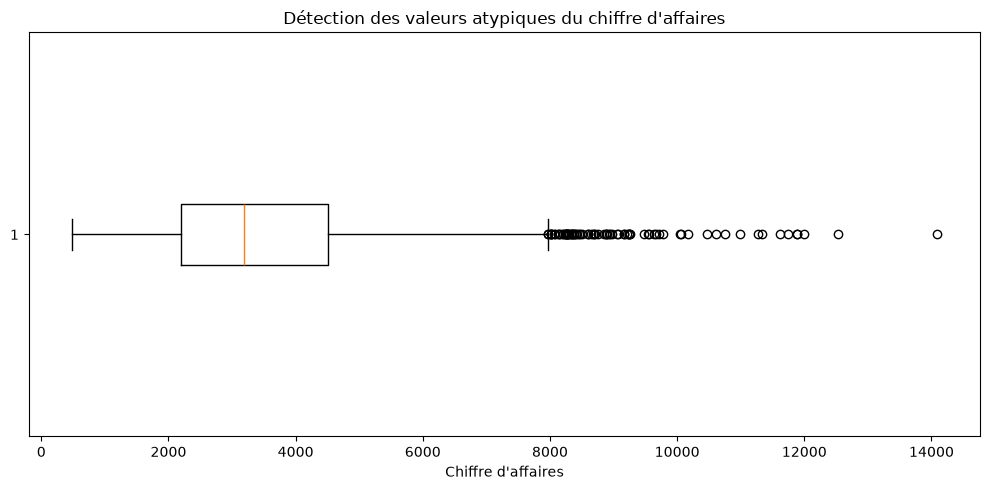

In [457]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["SALES"], vert=False)

plt.title("Détection des valeurs atypiques du chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")

plt.tight_layout()
plt.show()

### Lecture du graphique

Le boxplot met en évidence plusieurs observations situées au-delà de la limite supérieure de la distribution.

Ces observations correspondent aux valeurs identifiées par la méthode IQR et représentent environ **2,87 %** des lignes du dataset.

Leur faible proportion et leur cohérence avec certaines transactions de grande valeur justifient leur conservation après examen.

### Contrôle complémentaire de cohérence du chiffre d'affaires

Un contrôle exploratoire a comparé `SALES` à `QUANTITYORDERED × PRICEEACH`.

Cette vérification a identifié 1 304 lignes présentant une différence, soit 46,19 % des observations.

Toutefois, cette différence ne permet pas de conclure que `SALES` est erroné. La variable `PRICEEACH` ne permet pas systématiquement de reconstruire le chiffre d'affaires observé.

Aucune modification n'a donc été apportée à `SALES`, qui constitue la variable de chiffre d'affaires utilisée pour les analyses.

In [44]:
df["CALCULATED_SALES"] = (
    df["QUANTITYORDERED"] * df["PRICEEACH"]
)

df["SALES_DIFFERENCE"] = (
    df["SALES"] - df["CALCULATED_SALES"]
)

inconsistent_sales = df[
    df["SALES_DIFFERENCE"].abs() > 0.01
]

print("Nombre total de lignes :", len(df))
print(
    "Nombre de lignes incohérentes :",
    len(inconsistent_sales)
)
print(
    "Pourcentage de lignes incohérentes :",
    round(len(inconsistent_sales) / len(df) * 100, 2),
    "%"
)

Nombre total de lignes : 2823
Nombre de lignes incohérentes : 1304
Pourcentage de lignes incohérentes : 46.19 %


In [45]:
inconsistent_sales[
    [
        "ORDERNUMBER",
        "QUANTITYORDERED",
        "PRICEEACH",
        "SALES",
        "CALCULATED_SALES",
        "SALES_DIFFERENCE"
    ]
].head(20)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,CALCULATED_SALES,SALES_DIFFERENCE
4,10159,49,100.0,5205.27,4900.0,305.27
7,10188,48,100.0,5512.32,4800.0,712.32
9,10211,41,100.0,4708.44,4100.0,608.44
10,10223,37,100.0,3965.66,3700.0,265.66
11,10237,23,100.0,2333.12,2300.0,33.12
12,10251,28,100.0,3188.64,2800.0,388.64
13,10263,34,100.0,3676.76,3400.0,276.76
15,10285,36,100.0,4099.68,3600.0,499.68
16,10299,23,100.0,2597.39,2300.0,297.39
17,10309,41,100.0,4394.38,4100.0,294.38


# 8. Synthèse des principaux insights

L'analyse réalisée permet de dégager plusieurs résultats importants concernant la performance commerciale, la structure des ventes et l'évolution du chiffre d'affaires.

### 8.1 Performance commerciale globale

Le dataset contient **2 823 lignes de vente**, correspondant à **307 commandes uniques** et **92 clients uniques**.

Le chiffre d'affaires total s'élève à **10 032 628,85**, avec un chiffre d'affaires moyen de **3 553,89 par ligne de vente**.

Le chiffre d'affaires moyen par commande est de **32 679,57**, avec une médiane de **33 692,97**. La commande présentant le chiffre d'affaires le plus élevé atteint **77 809,37**.

### Interprétation

Ces indicateurs permettent de caractériser le niveau global de l'activité commerciale et constituent la base de référence pour les analyses qui suivent.

### 8.2 Concentration du chiffre d'affaires par gamme de produits

La répartition du chiffre d'affaires par gamme montre une forte concentration de la performance commerciale sur certaines catégories.

`Classic Cars` génère **39,07 % du chiffre d'affaires total**, ce qui en fait la première gamme du dataset.

`Vintage Cars` représente **18,97 %** du chiffre d'affaires.

Ainsi, ces deux gammes représentent ensemble **58,04 % du chiffre d'affaires total**.

### Interprétation

La performance commerciale est donc fortement concentrée sur `Classic Cars` et `Vintage Cars`.

Cette concentration constitue un élément important pour l'analyse de la structure des ventes : une part importante du chiffre d'affaires dépend de seulement deux gammes de produits.

### Décision

Ces deux gammes doivent être considérées comme les principales catégories contributrices au chiffre d'affaires dans la suite de l'analyse.

### 8.3 Principal marché

Les États-Unis constituent le principal marché observé dans le dataset avec un chiffre d'affaires de **3 627 982,83** et **1 004 lignes de vente**.

L'Espagne et la France arrivent ensuite, mais avec des niveaux de chiffre d'affaires nettement inférieurs.

### Interprétation

Les États-Unis constituent donc le principal contributeur au chiffre d'affaires parmi les marchés étudiés.

Cette performance est suffisamment importante pour être retenue comme un insight majeur de l'analyse.

Cependant, cette conclusion porte uniquement sur le chiffre d'affaires. Elle ne permet pas de conclure que les États-Unis constituent nécessairement le marché le plus rentable, car les données disponibles ne contiennent pas les coûts ni les marges.

### Décision

Le marché américain doit être considéré comme un marché prioritaire dans l'analyse de la performance commerciale. Une analyse complémentaire pourrait permettre de déterminer quels produits, tailles de vente et périodes expliquent cette performance.

### 8.4 Importance des différentes tailles de vente

Les ventes `Medium` génèrent **6 087 432,24**, soit **60,68 % du chiffre d'affaires total**.

Elles constituent donc le principal contributeur au chiffre d'affaires.

À l'inverse, les ventes `Large` sont beaucoup moins nombreuses, avec seulement **157 lignes**, mais leur chiffre d'affaires moyen par ligne atteint **8 293,75**, contre **4 398,43** pour `Medium` et **2 061,68** pour `Small`.

### Interprétation

Le segment `Medium` domine en contribution totale grâce à son volume important.

Le segment `Large`, bien que moins fréquent, présente une valeur moyenne par ligne nettement supérieure.

Cette différence montre qu'il faut distinguer **la contribution totale** d'un segment de **la valeur moyenne de ses transactions**.

### Décision

Les ventes `Medium` constituent le principal moteur du chiffre d'affaires en volume, tandis que les ventes `Large` représentent un segment à forte valeur unitaire qui mérite une attention particulière.

### 8.5 Progression du chiffre d'affaires

Le chiffre d'affaires est passé de **3 516 979,54 en 2003** à **4 724 162,60 en 2004**, soit une progression de **34,32 %**.

Les deux années étant complètes dans le dataset, cette comparaison constitue une mesure pertinente de l'évolution annuelle de l'activité.

L'année 2005 n'est pas utilisée pour une comparaison annuelle directe, car les données disponibles s'arrêtent au mois de mai.

### Interprétation

L'augmentation de **34,32 %** indique une progression importante du chiffre d'affaires entre les deux années complètes observées.

### Décision

La croissance de 34,32 % entre 2003 et 2004 constitue un **insight majeur** de l'analyse temporelle.

### 8.6 Concentration des ventes en fin d'année

L'analyse mensuelle montre une concentration récurrente du chiffre d'affaires en octobre et novembre.

Les deux mois ayant généré le chiffre d'affaires le plus élevé sont :

- **Novembre 2004 : 1 089 048,01**
- **Novembre 2003 : 1 029 837,66**

Les mois d'octobre présentent également des niveaux élevés :

- **Octobre 2003 : 568 290,97**
- **Octobre 2004 : 552 924,25**

### Interprétation

La répétition de cette concentration en octobre et novembre sur les deux années complètes observées suggère une **saisonnalité favorable aux ventes en fin d'année**.

Cependant, les données ne permettent pas de déterminer avec certitude la cause de cette hausse.

### Décision

La période **octobre-novembre** doit être considérée comme une période stratégique de forte activité dans l'analyse du dataset.

Cette observation peut justifier une préparation renforcée des stocks, des commandes et des opérations commerciales, sous réserve d'une validation sur davantage d'années.

### 8.7 Variables associées au chiffre d'affaires

L'analyse des corrélations montre les relations suivantes avec `SALES` :

- `PRICEEACH` : **0,6578**
- `MSRP` : **0,6352**
- `QUANTITYORDERED` : **0,5514**

Parmi ces variables, `PRICEEACH` présente donc la corrélation linéaire la plus forte avec le chiffre d'affaires.

### Interprétation

Les trois variables présentent une association positive avec `SALES`, mais avec des intensités différentes.

Le prix unitaire présente l'association linéaire la plus forte parmi les principales variables quantitatives étudiées.

### Limite

Une corrélation ne permet pas d'établir une causalité.

Ainsi, le coefficient de **0,6578** entre `PRICEEACH` et `SALES` ne signifie pas qu'une augmentation du prix provoque nécessairement une augmentation du chiffre d'affaires.

### Décision

Cette relation est retenue comme un **insight analytique secondaire**, mais elle doit être interprétée comme une association statistique et non comme une relation causale.

### 8.8 Synthèse des enseignements

Les principaux enseignements de l'analyse sont les suivants :

1. Le chiffre d'affaires total atteint **10 032 628,85** pour **307 commandes et 92 clients**.
2. `Classic Cars` représente **39,07 % du chiffre d'affaires**, tandis que `Classic Cars` et `Vintage Cars` représentent ensemble **58,04 %**.
3. Les États-Unis constituent le principal marché avec **3 627 982,83** de chiffre d'affaires.
4. Les ventes `Medium` représentent **60,68 % du chiffre d'affaires**, tandis que les ventes `Large` présentent la valeur moyenne par ligne la plus élevée.
5. Le chiffre d'affaires a progressé de **34,32 % entre 2003 et 2004**.
6. Une concentration récurrente des ventes est observée en **octobre et novembre**.
7. `PRICEEACH` présente la corrélation la plus forte avec `SALES` parmi les principales variables quantitatives étudiées, avec un coefficient de **0,6578**.
8. Les **81 observations potentiellement aberrantes** ont été conservées après examen, aucune preuve suffisante d'erreur n'ayant été identifiée.

Ces résultats constituent la base des recommandations formulées dans la section suivante.

# 9. Recommandations

### 9.1 Renforcer le suivi des gammes principales

`Classic Cars` représente **39,07 % du chiffre d'affaires**, tandis que `Vintage Cars` représente **18,97 %**. Ces deux gammes concentrent donc **58,04 % du chiffre d'affaires total**.

### Recommandation

Il est pertinent de suivre régulièrement la performance de ces deux gammes et d'identifier les facteurs expliquant leur forte contribution.

En parallèle, le développement des autres gammes peut permettre de diversifier la contribution au chiffre d'affaires et de réduire une éventuelle dépendance à ces deux catégories.

### 9.2 Préparer la période de forte activité

L'analyse temporelle montre une concentration récurrente des ventes en octobre et novembre.

Novembre 2004 représente le meilleur mois observé avec **1 089 048,01**, suivi de novembre 2003 avec **1 029 837,66**.

### Recommandation

Cette période devrait faire l'objet d'une préparation commerciale et opérationnelle renforcée, notamment concernant :

- la disponibilité des produits ;
- la gestion des stocks ;
- le traitement des commandes ;
- la capacité logistique ;
- les actions commerciales.

Cette recommandation doit toutefois être considérée comme une orientation à tester, car les données disponibles ne permettent pas d'identifier la cause exacte de la hausse observée.

### 9.3 Surveiller les ventes à forte valeur

Les ventes `Large` ne représentent que **157 lignes**, mais leur chiffre d'affaires moyen atteint **8 293,75**, contre **4 398,43** pour les ventes `Medium` et **2 061,68** pour les ventes `Small`.

### Recommandation

Il serait pertinent d'analyser plus précisément les caractéristiques des ventes `Large` afin d'identifier les produits, marchés et périodes associés aux transactions de forte valeur.

L'objectif serait de mieux comprendre les conditions associées à ces ventes et d'évaluer les possibilités de reproduire ce type de performance.

### 9.4 Approfondir l'analyse du marché américain

Les États-Unis constituent le principal marché observé avec **3 627 982,83** de chiffre d'affaires et **1 004 lignes de vente**.

### Recommandation

Une analyse complémentaire devrait permettre d'identifier les produits, tailles de vente et périodes qui contribuent le plus à cette performance.

Cela permettrait de déterminer si la forte performance américaine repose principalement sur le volume des ventes, certaines gammes de produits ou certaines périodes de l'année.

### 9.5 Compléter l'analyse par la rentabilité

L'analyse réalisée porte principalement sur le chiffre d'affaires.

Or, un chiffre d'affaires élevé ne signifie pas nécessairement qu'un produit, un pays ou une commande est plus rentable.

### Recommandation

Si les données sont disponibles, il serait pertinent d'intégrer :

- les coûts d'achat ;
- les coûts logistiques ;
- les marges ;
- les dépenses commerciales ;
- le bénéfice.

Cela permettrait de passer d'une analyse de la performance en chiffre d'affaires à une analyse réelle de la rentabilité.

### 9.6 Confirmer la saisonnalité sur une période plus longue

L'analyse montre une concentration des ventes en octobre et novembre sur les deux années complètes disponibles.

### Recommandation

Une analyse portant sur davantage d'années complètes permettrait de vérifier si cette concentration constitue une saisonnalité réellement récurrente ou si elle résulte de circonstances particulières aux années observées.

Il serait également utile de disposer d'informations supplémentaires sur les promotions, campagnes commerciales et événements susceptibles d'expliquer les pics observés.

### 9.7 Approfondir l'analyse des facteurs associés au chiffre d'affaires

`PRICEEACH` présente une corrélation de **0,6578** avec `SALES`, tandis que `QUANTITYORDERED` présente une corrélation de **0,5514**.

### Recommandation

Ces relations peuvent servir de point de départ à des analyses complémentaires, mais elles ne doivent pas être utilisées seules pour prendre une décision commerciale.

Il serait pertinent d'intégrer d'autres variables, notamment le produit, le pays, la taille de vente et la période, afin de mieux comprendre les facteurs associés au chiffre d'affaires.

La corrélation ne permettant pas d'établir la causalité, toute décision basée sur ces relations devrait être confirmée par une analyse complémentaire.

### 9.8 Conserver et surveiller les transactions atypiques

La méthode IQR a identifié **81 observations potentiellement aberrantes**, soit environ **2,87 %** des lignes.

Après examen, aucune preuve suffisante ne permettait de les considérer comme des erreurs.

### Recommandation

Ces observations doivent être conservées dans l'analyse, tout en pouvant faire l'objet d'un suivi spécifique.

Une analyse complémentaire pourrait notamment déterminer si ces transactions de forte valeur sont liées à certaines gammes, certains clients, certains marchés ou certaines périodes.

### 9.9 Synthèse des recommandations

Les principales recommandations issues de l'analyse sont les suivantes :

1. **Surveiller les gammes `Classic Cars` et `Vintage Cars`**, qui représentent ensemble 58,04 % du chiffre d'affaires.
2. **Préparer particulièrement la période octobre-novembre**, qui présente les plus forts niveaux de chiffre d'affaires observés.
3. **Analyser les ventes `Large`**, qui sont peu nombreuses mais présentent une valeur moyenne élevée.
4. **Approfondir l'analyse du marché américain**, principal contributeur au chiffre d'affaires.
5. **Compléter l'analyse du chiffre d'affaires par une analyse de rentabilité** lorsque les données de coûts et de marges sont disponibles.
6. **Vérifier la saisonnalité sur davantage d'années complètes**.
7. **Interpréter les corrélations avec prudence** et compléter l'analyse par d'autres méthodes.
8. **Conserver les valeurs atypiques légitimes** plutôt que de les supprimer automatiquement.

# 10. Conclusion générale

### 10.1 Bilan de la démarche

L'analyse a suivi une démarche structurée comprenant plusieurs étapes : compréhension du dataset, diagnostic de la qualité des données, traitement des valeurs manquantes, vérification des doublons, préparation des variables temporelles, exploration des données, analyse temporelle, étude des relations entre variables et détection des valeurs atypiques.

Le dataset initial comprenait **2 823 lignes et 25 variables**.

Le nettoyage a permis de traiter les valeurs manquantes identifiées dans `ADDRESSLINE2`, `STATE`, `POSTALCODE` et `TERRITORY`, pour un total initial de **5 157 valeurs manquantes**.

Après traitement, aucune valeur manquante ne subsiste dans le dataset et aucun doublon n'a été détecté.

### 10.2 Principaux résultats

L'analyse commerciale a permis d'identifier plusieurs résultats majeurs.

Le chiffre d'affaires total s'élève à **10 032 628,85**, pour **307 commandes uniques** et **92 clients uniques**.

La gamme `Classic Cars` représente **39,07 % du chiffre d'affaires**, tandis que `Classic Cars` et `Vintage Cars` représentent ensemble **58,04 %**.

Les États-Unis constituent le principal marché avec **3 627 982,83 de chiffre d'affaires** et **1 004 lignes de vente**.

Les ventes `Medium` représentent **60,68 % du chiffre d'affaires total**, tandis que les ventes `Large`, bien que moins nombreuses, présentent le chiffre d'affaires moyen par ligne le plus élevé, avec **8 293,75**.

L'analyse temporelle montre une progression de **34,32 % du chiffre d'affaires entre 2003 et 2004**.

Elle révèle également une concentration récurrente des ventes en octobre et novembre, avec un maximum de **1 089 048,01 en novembre 2004**.

Enfin, l'analyse des corrélations montre que `PRICEEACH` présente la relation linéaire la plus forte avec `SALES` parmi les principales variables quantitatives étudiées, avec un coefficient de **0,6578**.

### 10.3 Limites de l'analyse

Plusieurs limites doivent être prises en compte dans l'interprétation des résultats.

Premièrement, l'année **2005 est partielle**, puisque les données disponibles s'arrêtent au mois de mai. Elle ne peut donc pas être comparée directement à 2003 et 2004 en termes de chiffre d'affaires annuel.

Deuxièmement, l'analyse de la saisonnalité repose principalement sur **deux années complètes**, ce qui constitue un nombre limité de cycles annuels pour confirmer définitivement une tendance saisonnière.

Troisièmement, l'analyse porte principalement sur le **chiffre d'affaires** et ne permet pas d'évaluer directement la rentabilité, car les informations relatives aux coûts et aux marges ne sont pas disponibles.

Quatrièmement, les corrélations observées entre les variables ne permettent pas d'établir de relations causales.

Enfin, les **81 observations potentiellement aberrantes** détectées par la méthode IQR ont été conservées, car aucune preuve suffisante ne permettait de les considérer comme des erreurs.

### 10.4 Conclusion finale

Au terme de cette analyse, le dataset présente une structure exploitable pour l'étude de la performance commerciale après les opérations de nettoyage et de préparation réalisées.

Les résultats montrent une activité commerciale principalement portée par les gammes `Classic Cars` et `Vintage Cars`, avec une contribution particulièrement importante du marché américain. L'analyse met également en évidence une progression significative du chiffre d'affaires entre 2003 et 2004 ainsi qu'une concentration des ventes en octobre et novembre.

Ces résultats permettent d'identifier plusieurs axes d'attention : le suivi des principales gammes de produits, la préparation des périodes de forte activité, l'analyse des transactions à forte valeur et l'approfondissement de la performance des principaux marchés.

Cependant, ces conclusions doivent être interprétées dans le contexte des limites du dataset. L'intégration de données supplémentaires sur les coûts, les marges, les actions commerciales et plusieurs années supplémentaires permettrait de renforcer les conclusions et de passer d'une analyse descriptive à une analyse plus approfondie de la performance et de la rentabilité.

Ainsi, cette étude fournit une première base fiable pour comprendre la structure et l'évolution des ventes et pour orienter de futures analyses décisionnelles.